In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
behavior_columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

behaviors = pd.read_csv(
    "C:\\Users\\admin\\ML_RESUME_PROJECT\\behaviors.tsv",
    sep="\t",
    names=behavior_columns
)

print("Shape:", behaviors.shape)
behaviors.head()

Shape: (156965, 5)


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [5]:
news_columns = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

news = pd.read_csv(
    "C:\\Users\\admin\\ML_RESUME_PROJECT\\news.tsv",
    sep="\t",
    names=news_columns
)

print("Shape:", news.shape)
news.head()

Shape: (51282, 8)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [6]:
print("BEHAVIORS DATASET")
print("------------------")
print("Rows:", len(behaviors))
print("Unique users:", behaviors["user_id"].nunique())
print("Missing values:")
print(behaviors.isnull().sum())

print("\nNEWS DATASET")
print("------------")
print("Rows:", len(news))
print("Unique articles:", news["news_id"].nunique())
print("Categories:", news["category"].nunique())
print("Subcategories:", news["subcategory"].nunique())
print("Missing values:")
print(news.isnull().sum())

BEHAVIORS DATASET
------------------
Rows: 156965
Unique users: 50000
Missing values:
impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64

NEWS DATASET
------------
Rows: 51282
Unique articles: 51282
Categories: 17
Subcategories: 264
Missing values:
news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64


category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64


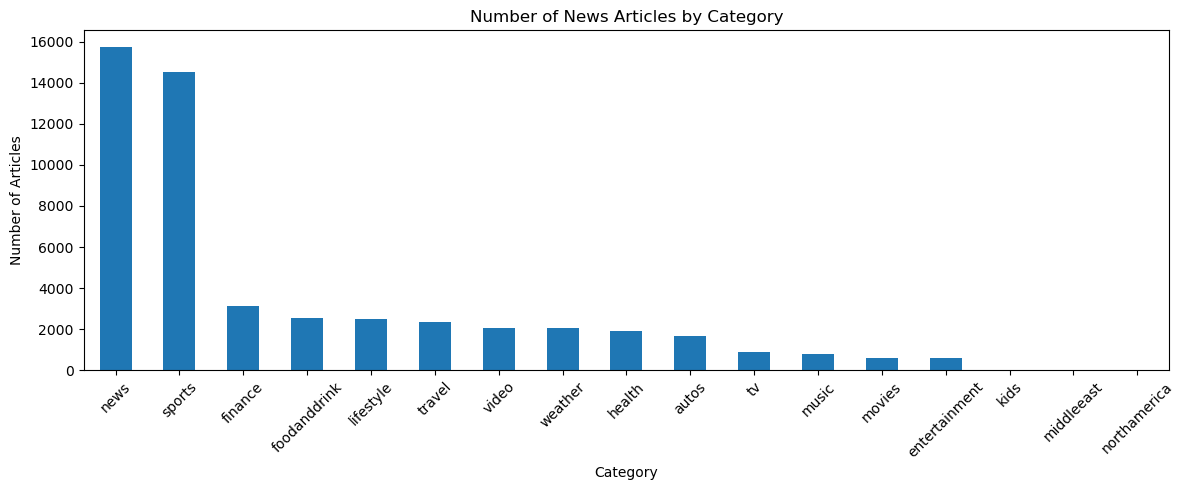

In [7]:
category_counts = news["category"].value_counts()

print(category_counts)

category_counts.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Number of News Articles by Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

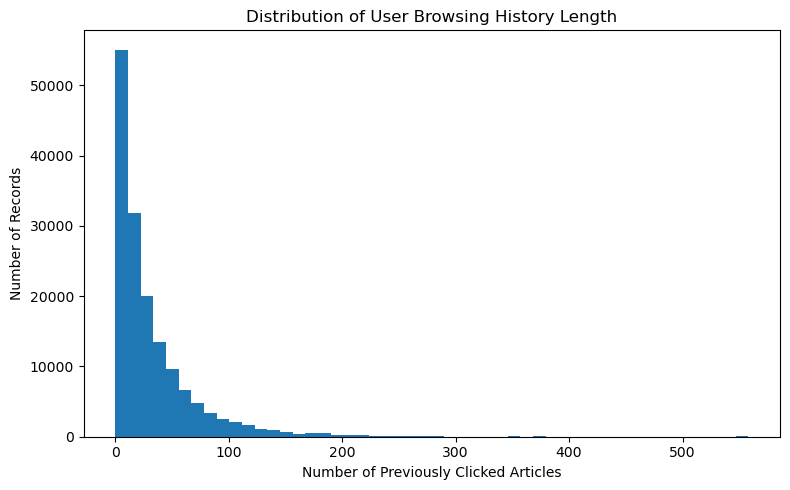

In [9]:
behaviors["history_length"] = (
    behaviors["history"]
    .fillna("")
    .apply(lambda x: len(x.split()) if x else 0)
)

behaviors["history_length"].describe()

plt.figure(figsize=(8, 5))

plt.hist(
    behaviors["history_length"],
    bins=50
)

plt.title("Distribution of User Browsing History Length")
plt.xlabel("Number of Previously Clicked Articles")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [11]:
def count_impressions(impression_string):
    if pd.isna(impression_string):
        return 0
    return len(impression_string.split())


def count_clicks(impression_string):
    if pd.isna(impression_string):
        return 0
    
    items = impression_string.split()
    return sum(item.endswith("-1") for item in items)


behaviors["impression_count"] = behaviors["impressions"].apply(count_impressions)
behaviors["click_count"] = behaviors["impressions"].apply(count_clicks)

behaviors[
    ["user_id", "impression_count", "click_count", "history_length"]
].head(10)

behaviors["ctr"] = (
    behaviors["click_count"] /
    behaviors["impression_count"]
)

behaviors["ctr"].describe()

count    156965.000000
mean          0.108544
std           0.129495
min           0.003367
25%           0.028571
50%           0.055556
75%           0.125000
max           0.750000
Name: ctr, dtype: float64

Impressions:
count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_count, dtype: float64

Clicks:
count    156965.000000
mean          1.505711
std           1.153102
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          35.000000
Name: click_count, dtype: float64

CTR:
count    156965.000000
mean          0.108544
std           0.129495
min           0.003367
25%           0.028571
50%           0.055556
75%           0.125000
max           0.750000
Name: ctr, dtype: float64

History Length:
count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_length, dtype: float64


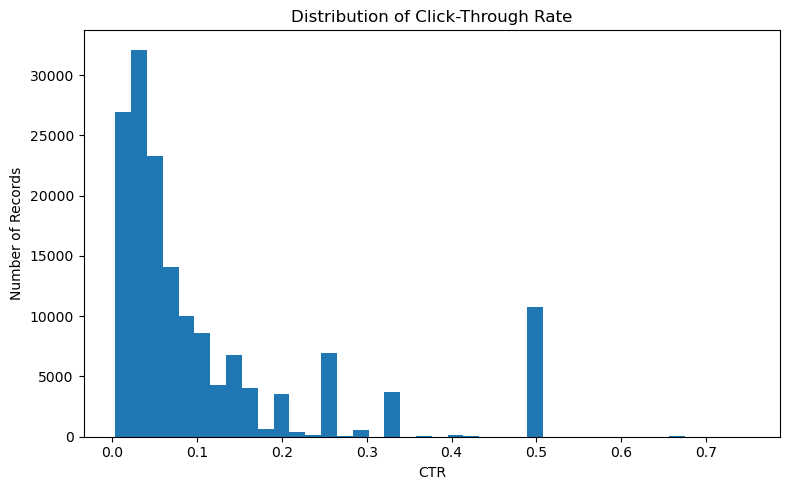

In [12]:
print("Impressions:")
print(behaviors["impression_count"].describe())

print("\nClicks:")
print(behaviors["click_count"].describe())

print("\nCTR:")
print(behaviors["ctr"].describe())

print("\nHistory Length:")
print(behaviors["history_length"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    behaviors["ctr"],
    bins=40
)

plt.title("Distribution of Click-Through Rate")
plt.xlabel("CTR")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()